# Transformer (Attention Is All You Need)

In [1]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## Embeddings

In [2]:
class Embeddings(nn.Module):
    def __init__(self, vocab_size, d_model):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model)
        self.d_model = d_model

    def forward(self, x):
        return self.embed(x) * math.sqrt(self.d_model)

## Positional Encoding

In [3]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

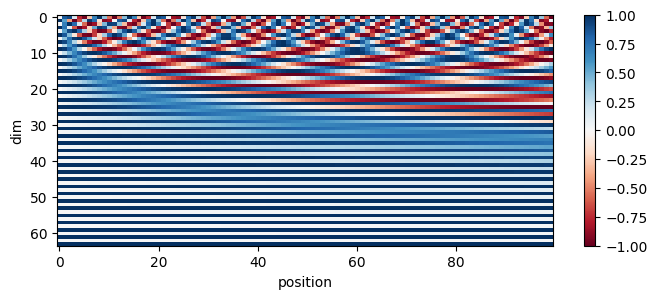

In [4]:
pe = PositionalEncoding(64, dropout=0.0, max_len=100)
plt.figure(figsize=(8, 3))
plt.imshow(pe.pe[0, :100, :64].numpy().T, aspect="auto", cmap="RdBu")
plt.xlabel("position"); plt.ylabel("dim")
plt.colorbar()
plt.show()

## Scaled Dot-Product Attention

In [5]:
def attention(query, key, value, mask=None, dropout=None):
    d_k = query.size(-1)
    scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(d_k)

    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)

    attn = torch.softmax(scores, dim=-1)
    if dropout is not None:
        attn = dropout(attn)

    output = torch.matmul(attn, value)
    return output, attn

## Multi-Head Attention

In [6]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, h, dropout=0.1):
        super().__init__()
        assert d_model % h == 0
        self.d_k = d_model // h
        self.h = h

        self.q_linear = nn.Linear(d_model, d_model)
        self.k_linear = nn.Linear(d_model, d_model)
        self.v_linear = nn.Linear(d_model, d_model)
        self.out_linear = nn.Linear(d_model, d_model)

        self.dropout = nn.Dropout(dropout)
        self.attn = None

    def forward(self, query, key, value, mask=None):
        batch_size = query.size(0)

        Q = self.q_linear(query)
        K = self.k_linear(key)
        V = self.v_linear(value)

        Q = Q.view(batch_size, -1, self.h, self.d_k).transpose(1, 2)
        K = K.view(batch_size, -1, self.h, self.d_k).transpose(1, 2)
        V = V.view(batch_size, -1, self.h, self.d_k).transpose(1, 2)

        if mask is not None:
            mask = mask.unsqueeze(1)

        out, self.attn = attention(Q, K, V, mask, self.dropout)

        out = out.transpose(1, 2).contiguous().view(batch_size, -1, self.h * self.d_k)
        return self.out_linear(out)

## Feed Forward

In [7]:
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.linear2(self.dropout(F.relu(self.linear1(x))))

## Encoder

In [8]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, h, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, h, dropout)
        self.feed_forward = FeedForward(d_model, d_ff, dropout)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, mask):
        attn_out = self.self_attn(x, x, x, mask)
        x = self.norm1(x + self.dropout1(attn_out))

        ff_out = self.feed_forward(x)
        x = self.norm2(x + self.dropout2(ff_out))
        return x


class Encoder(nn.Module):
    def __init__(self, d_model, h, d_ff, N, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([EncoderLayer(d_model, h, d_ff, dropout) for _ in range(N)])
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x, mask):
        for layer in self.layers:
            x = layer(x, mask)
        return self.norm(x)

## Masks

In [9]:
def make_padding_mask(seq, pad_idx=0):
    return (seq != pad_idx).unsqueeze(-2)


def subsequent_mask(size):
    mask = torch.triu(torch.ones(1, size, size), diagonal=1)
    return mask == 0


def make_decoder_mask(tgt, pad_idx=0):
    pad_mask = make_padding_mask(tgt, pad_idx)
    sub_mask = subsequent_mask(tgt.size(-1)).type_as(pad_mask)
    return pad_mask & sub_mask

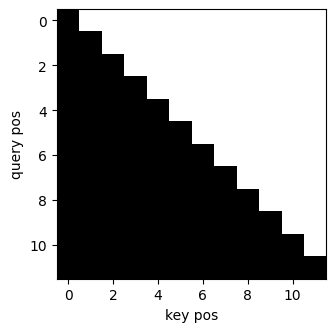

In [10]:
plt.figure(figsize=(3.5, 3.5))
plt.imshow(subsequent_mask(12)[0], cmap="Greys")
plt.xlabel("key pos"); plt.ylabel("query pos")
plt.show()

## Decoder

In [11]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, h, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, h, dropout)
        self.cross_attn = MultiHeadAttention(d_model, h, dropout)
        self.feed_forward = FeedForward(d_model, d_ff, dropout)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, x, memory, src_mask, tgt_mask):
        attn_out = self.self_attn(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout1(attn_out))

        cross_out = self.cross_attn(x, memory, memory, src_mask)
        x = self.norm2(x + self.dropout2(cross_out))

        ff_out = self.feed_forward(x)
        x = self.norm3(x + self.dropout3(ff_out))
        return x


class Decoder(nn.Module):
    def __init__(self, d_model, h, d_ff, N, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([DecoderLayer(d_model, h, d_ff, dropout) for _ in range(N)])
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x, memory, src_mask, tgt_mask):
        for layer in self.layers:
            x = layer(x, memory, src_mask, tgt_mask)
        return self.norm(x)

## Output Layer

In [12]:
class Generator(nn.Module):
    def __init__(self, d_model, vocab_size):
        super().__init__()
        self.proj = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        return F.log_softmax(self.proj(x), dim=-1)

## Full Model

In [13]:
class Transformer(nn.Module):
    def __init__(self, encoder, decoder, src_embed, tgt_embed, generator):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.src_embed = src_embed
        self.tgt_embed = tgt_embed
        self.generator = generator

    def encode(self, src, src_mask):
        return self.encoder(self.src_embed(src), src_mask)

    def decode(self, memory, src_mask, tgt, tgt_mask):
        return self.decoder(self.tgt_embed(tgt), memory, src_mask, tgt_mask)

    def forward(self, src, tgt, src_mask, tgt_mask):
        memory = self.encode(src, src_mask)
        return self.decode(memory, src_mask, tgt, tgt_mask)


def make_model(src_vocab, tgt_vocab, N=6, d_model=512, d_ff=2048, h=8, dropout=0.1):
    model = Transformer(
        encoder=Encoder(d_model, h, d_ff, N, dropout),
        decoder=Decoder(d_model, h, d_ff, N, dropout),
        src_embed=nn.Sequential(Embeddings(src_vocab, d_model), PositionalEncoding(d_model, dropout)),
        tgt_embed=nn.Sequential(Embeddings(tgt_vocab, d_model), PositionalEncoding(d_model, dropout)),
        generator=Generator(d_model, tgt_vocab),
    )

    for p in model.parameters():
        if p.dim() > 1:
            nn.init.xavier_uniform_(p)

    return model

## Build Model

In [14]:
SRC_VOCAB_SIZE = 10_000
TGT_VOCAB_SIZE = 10_000

model = make_model(SRC_VOCAB_SIZE, TGT_VOCAB_SIZE, N=6, d_model=512, d_ff=2048, h=8, dropout=0.1).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\ntotal params: {n_params:,}")

Transformer(
  (encoder): Encoder(
    (layers): ModuleList(
      (0-5): 6 x EncoderLayer(
        (self_attn): MultiHeadAttention(
          (q_linear): Linear(in_features=512, out_features=512, bias=True)
          (k_linear): Linear(in_features=512, out_features=512, bias=True)
          (v_linear): Linear(in_features=512, out_features=512, bias=True)
          (out_linear): Linear(in_features=512, out_features=512, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (feed_forward): FeedForward(
          (linear1): Linear(in_features=512, out_features=2048, bias=True)
          (linear2): Linear(in_features=2048, out_features=512, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )


## Forward Pass Test

In [15]:
torch.manual_seed(0)
src = torch.randint(1, SRC_VOCAB_SIZE, (2, 10)).to(device)
tgt = torch.randint(1, TGT_VOCAB_SIZE, (2, 9)).to(device)
src[0, -2:] = 0

src_mask = make_padding_mask(src, 0).to(device)
tgt_mask = make_decoder_mask(tgt, 0).to(device)

model.eval()
with torch.no_grad():
    memory = model.encode(src, src_mask)
    out = model.decode(memory, src_mask, tgt, tgt_mask)
    logits = model.generator(out)

print("src            :", src.shape)
print("encoder output :", memory.shape)
print("decoder output :", out.shape)
print("logits         :", logits.shape)

src            : torch.Size([2, 10])
encoder output : torch.Size([2, 10, 512])
decoder output : torch.Size([2, 9, 512])
logits         : torch.Size([2, 9, 10000])


## Attention Visualization

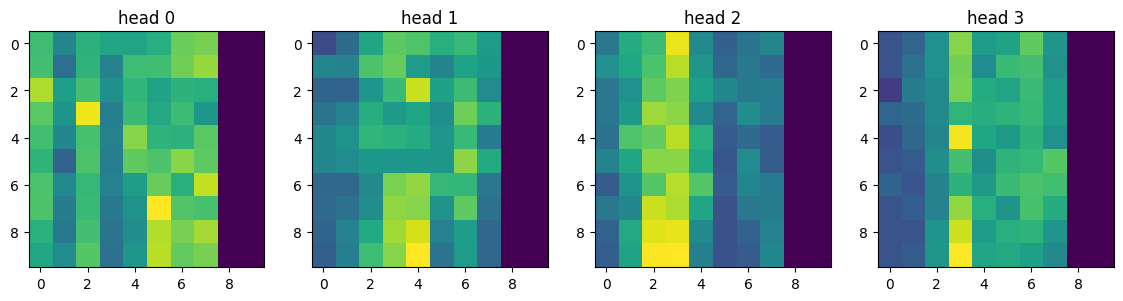

In [16]:
attn_weights = model.encoder.layers[0].self_attn.attn

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for i, ax in enumerate(axes):
    ax.imshow(attn_weights[0, i].cpu().numpy(), cmap="viridis")
    ax.set_title(f"head {i}")
plt.show()

## Quick Training Check (Copy Task)

In [17]:
class LabelSmoothing(nn.Module):
    def __init__(self, vocab_size, pad_idx, smoothing=0.1):
        super().__init__()
        self.criterion = nn.KLDivLoss(reduction="sum")
        self.pad_idx = pad_idx
        self.confidence = 1.0 - smoothing
        self.smoothing = smoothing
        self.vocab_size = vocab_size

    def forward(self, x, target):
        true_dist = x.data.clone()
        true_dist.fill_(self.smoothing / (self.vocab_size - 2))
        true_dist.scatter_(1, target.data.unsqueeze(1), self.confidence)
        true_dist[:, self.pad_idx] = 0

        pad_rows = (target.data == self.pad_idx).nonzero()
        if pad_rows.numel() > 0:
            true_dist.index_fill_(0, pad_rows.squeeze(1), 0.0)

        return self.criterion(x, true_dist.detach())

## Learning Rate Schedule

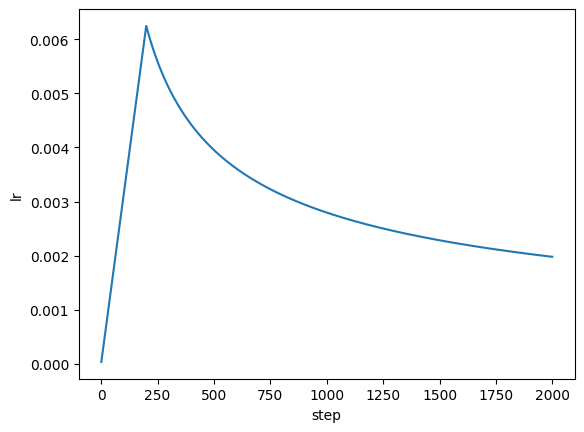

In [18]:
def lr_schedule(step, d_model, warmup=200):
    step = max(step, 1)
    return d_model ** -0.5 * min(step ** -0.5, step * warmup ** -1.5)

steps = range(1, 2000)
plt.plot(steps, [lr_schedule(s, 128) for s in steps])
plt.xlabel("step"); plt.ylabel("lr")
plt.show()

## Copy Task Data

In [19]:
def data_gen(vocab_size, batch_size, nbatches, seq_len=10):
    for _ in range(nbatches):
        data = torch.randint(1, vocab_size, (batch_size, seq_len))
        data[:, 0] = 1
        yield data.clone(), data.clone()


def make_batch(src, tgt, pad_idx=0):
    src_mask = make_padding_mask(src, pad_idx)
    tgt_in = tgt[:, :-1]
    tgt_out = tgt[:, 1:]
    tgt_mask = make_decoder_mask(tgt_in, pad_idx)
    ntokens = (tgt_out != pad_idx).sum()
    return src, tgt_in, tgt_out, src_mask, tgt_mask, ntokens

## Train the Model

In [20]:
VOCAB = 11

small_model = make_model(VOCAB, VOCAB, N=2, d_model=128, d_ff=512, h=4, dropout=0.1).to(device)
criterion = LabelSmoothing(VOCAB, pad_idx=0, smoothing=0.1)
optimizer = torch.optim.Adam(small_model.parameters(), lr=1.0, betas=(0.9, 0.98), eps=1e-9)
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lambda step: lr_schedule(step, 128))

In [21]:
def run_epoch(data_iter, model, criterion, optimizer, scheduler, pad_idx=0):
    model.train()
    total_loss, total_tokens = 0.0, 0

    for src, tgt in data_iter:
        src, tgt = src.to(device), tgt.to(device)
        src, tgt_in, tgt_out, src_mask, tgt_mask, ntokens = make_batch(src, tgt, pad_idx)

        out = model(src, tgt_in, src_mask, tgt_mask)
        logits = model.generator(out)
        loss = criterion(logits.view(-1, logits.size(-1)), tgt_out.contiguous().view(-1)) / ntokens

        loss.backward()
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        total_loss += loss.item() * ntokens.item()
        total_tokens += ntokens.item()

    return total_loss / total_tokens

epoch  1  loss = 1.9966
epoch  2  loss = 1.5682
epoch  3  loss = 1.4646
epoch  4  loss = 1.3804
epoch  5  loss = 1.2917
epoch  6  loss = 1.2318
epoch  7  loss = 1.1582
epoch  8  loss = 1.1174
epoch  9  loss = 1.0645
epoch 10  loss = 1.0753
epoch 11  loss = 1.0394
epoch 12  loss = 1.0189
epoch 13  loss = 0.9568
epoch 14  loss = 0.8982
epoch 15  loss = 0.8180
epoch 16  loss = 0.7871
epoch 17  loss = 0.7480
epoch 18  loss = 0.6127
epoch 19  loss = 0.6222
epoch 20  loss = 0.5752
epoch 21  loss = 0.5520
epoch 22  loss = 0.4624
epoch 23  loss = 0.4241
epoch 24  loss = 0.4047
epoch 25  loss = 0.3930


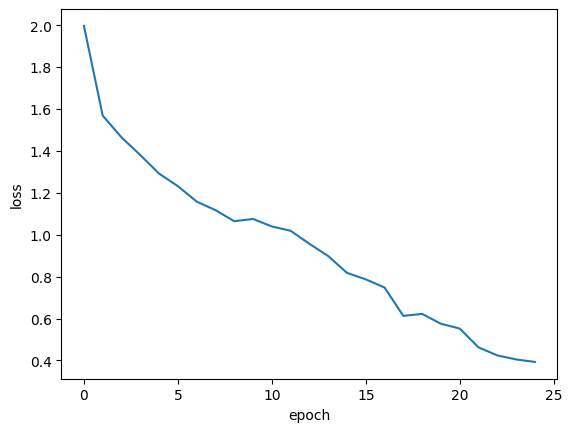

In [22]:
losses = []
for epoch in range(25):
    data_iter = data_gen(VOCAB, batch_size=30, nbatches=20)
    loss = run_epoch(data_iter, small_model, criterion, optimizer, scheduler)
    losses.append(loss)
    print(f"epoch {epoch + 1:2d}  loss = {loss:.4f}")

plt.plot(losses)
plt.xlabel("epoch"); plt.ylabel("loss")
plt.show()

## Test the Trained Model

In [23]:
def greedy_decode(model, src, src_mask, max_len, start_symbol=1):
    memory = model.encode(src, src_mask)
    ys = torch.full((1, 1), start_symbol, dtype=torch.long, device=device)

    for _ in range(max_len - 1):
        out = model.decode(memory, src_mask, ys, subsequent_mask(ys.size(1)).to(device))
        next_word = model.generator(out[:, -1]).argmax(dim=-1).item()
        ys = torch.cat([ys, torch.full((1, 1), next_word, dtype=torch.long, device=device)], dim=1)

    return ys

In [24]:
small_model.eval()
matches = []

for _ in range(5):
    test_src = torch.randint(1, VOCAB, (1, 10)).to(device)
    test_src[0, 0] = 1
    test_mask = make_padding_mask(test_src, 0).to(device)

    pred = greedy_decode(small_model, test_src, test_mask, max_len=10)
    match = (test_src[0] == pred[0]).float().mean().item()
    matches.append(match)

    print("input :", test_src[0].tolist())
    print("output:", pred[0].tolist())
    print(f"match : {match:.0%}\n")

print(f"average match: {sum(matches) / len(matches):.0%}")

input : [1, 4, 6, 8, 5, 2, 2, 3, 5, 2]
output: [1, 4, 6, 8, 5, 2, 2, 3, 5, 2]
match : 100%

input : [1, 9, 8, 9, 9, 4, 3, 9, 5, 8]
output: [1, 9, 8, 9, 4, 9, 4, 9, 5, 8]
match : 70%

input : [1, 9, 4, 2, 8, 7, 5, 3, 8, 9]
output: [1, 9, 4, 2, 8, 7, 5, 3, 8, 9]
match : 100%

input : [1, 1, 4, 7, 5, 3, 2, 6, 6, 7]
output: [1, 1, 4, 7, 5, 3, 2, 6, 6, 6]
match : 90%

input : [1, 2, 2, 5, 5, 5, 1, 10, 3, 9]
output: [1, 2, 2, 5, 5, 5, 1, 10, 3, 9]
match : 100%

average match: 92%


## Real Training: Multi30k (English → German)

*Uses the base config (`N=6, d_model=512, h=8, d_ff=2048`) on a T4 GPU if available. On CPU it auto-switches to a smaller config so this still runs, just for a quick check.*

In [25]:
import urllib.request, gzip, os

BASE_URL = "https://raw.githubusercontent.com/multi30k/dataset/master/data/task1/raw/"
FILES = ["train.en", "train.de", "val.en", "val.de"]

os.makedirs("data", exist_ok=True)
for name in FILES:
    path = f"data/{name}"
    if not os.path.exists(path):
        urllib.request.urlretrieve(BASE_URL + name + ".gz", path + ".gz")
        with gzip.open(path + ".gz", "rt", encoding="utf-8") as f_in, open(path, "w", encoding="utf-8") as f_out:
            f_out.write(f_in.read())

def read_lines(path):
    with open(path, encoding="utf-8") as f:
        return [line.strip() for line in f]

train_en = read_lines("data/train.en")
train_de = read_lines("data/train.de")
val_en = read_lines("data/val.en")
val_de = read_lines("data/val.de")

print(len(train_en), "training pairs,", len(val_en), "validation pairs")
print(train_en[0])
print(train_de[0])

29000 training pairs, 1014 validation pairs
Two young, White males are outside near many bushes.
Zwei junge weiße Männer sind im Freien in der Nähe vieler Büsche.


## Train a BPE Tokenizer

In [26]:
!pip install -q tokenizers sacrebleu

In [27]:
from tokenizers import Tokenizer, models, trainers, pre_tokenizers, processors

tokenizer = Tokenizer(models.BPE(unk_token="<unk>"))
tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()

trainer = trainers.BpeTrainer(vocab_size=8000, special_tokens=["<pad>", "<bos>", "<eos>", "<unk>"])
tokenizer.train(files=["data/train.en", "data/train.de"], trainer=trainer)

PAD_ID = tokenizer.token_to_id("<pad>")
BOS_ID = tokenizer.token_to_id("<bos>")
EOS_ID = tokenizer.token_to_id("<eos>")
VOCAB_SIZE = tokenizer.get_vocab_size()

tokenizer.post_processor = processors.TemplateProcessing(
    single="<bos> $A <eos>",
    special_tokens=[("<bos>", BOS_ID), ("<eos>", EOS_ID)],
)

print("vocab size:", VOCAB_SIZE, "| pad:", PAD_ID, "bos:", BOS_ID, "eos:", EOS_ID)
print(tokenizer.encode(train_en[0]).tokens)

vocab size: 8000 | pad: 0 bos: 1 eos: 2
['<bos>', 'Two', 'young', ',', 'White', 'males', 'are', 'outside', 'near', 'many', 'bushes', '.', '<eos>']


## Dataset and Batching

In [28]:
class TranslationDataset(torch.utils.data.Dataset):
    def __init__(self, src_sentences, tgt_sentences):
        self.src = [tokenizer.encode(s).ids for s in src_sentences]
        self.tgt = [tokenizer.encode(s).ids for s in tgt_sentences]

    def __len__(self):
        return len(self.src)

    def __getitem__(self, idx):
        return self.src[idx], self.tgt[idx]


def collate_batch(batch):
    src_seqs, tgt_seqs = zip(*batch)
    src_max = max(len(s) for s in src_seqs)
    tgt_max = max(len(t) for t in tgt_seqs)

    src_batch = torch.full((len(batch), src_max), PAD_ID, dtype=torch.long)
    tgt_batch = torch.full((len(batch), tgt_max), PAD_ID, dtype=torch.long)
    for i, (s, t) in enumerate(zip(src_seqs, tgt_seqs)):
        src_batch[i, :len(s)] = torch.tensor(s)
        tgt_batch[i, :len(t)] = torch.tensor(t)
    return src_batch, tgt_batch


train_dataset = TranslationDataset(train_en, train_de)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True, collate_fn=collate_batch)
print("batches per epoch:", len(train_loader))

batches per epoch: 227


## Build and Train the Model

In [29]:
if torch.cuda.is_available():
    N, D_MODEL, D_FF, H, EPOCHS, WARMUP = 6, 512, 2048, 8, 20, 4000
else:
    N, D_MODEL, D_FF, H, EPOCHS, WARMUP = 2, 128, 512, 4, 2, 100

mt_model = make_model(VOCAB_SIZE, VOCAB_SIZE, N=N, d_model=D_MODEL, d_ff=D_FF, h=H, dropout=0.1).to(device)
mt_criterion = LabelSmoothing(VOCAB_SIZE, pad_idx=PAD_ID, smoothing=0.1)
mt_optimizer = torch.optim.Adam(mt_model.parameters(), lr=1.0, betas=(0.9, 0.98), eps=1e-9)
mt_scheduler = torch.optim.lr_scheduler.LambdaLR(mt_optimizer, lambda step: lr_schedule(step, D_MODEL, warmup=WARMUP))

print(f"{sum(p.numel() for p in mt_model.parameters()):,} params, training for {EPOCHS} epochs on {device}")

56,436,544 params, training for 20 epochs on cuda


epoch  1  loss = 6.5274
epoch  2  loss = 4.7120
epoch  3  loss = 4.0547
epoch  4  loss = 3.5521
epoch  5  loss = 3.2096
epoch  6  loss = 2.9511
epoch  7  loss = 2.7472
epoch  8  loss = 2.5637
epoch  9  loss = 2.4001
epoch 10  loss = 2.2489
epoch 11  loss = 2.1177
epoch 12  loss = 1.9990
epoch 13  loss = 1.8974
epoch 14  loss = 1.8088
epoch 15  loss = 1.7316
epoch 16  loss = 1.6624
epoch 17  loss = 1.6047
epoch 18  loss = 1.5546
epoch 19  loss = 1.4747
epoch 20  loss = 1.3852


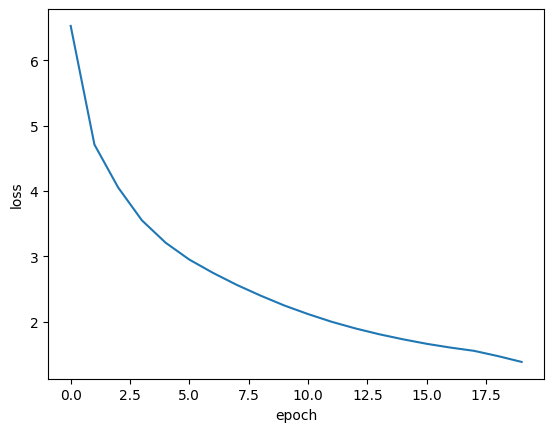

In [30]:
mt_losses = []
for epoch in range(EPOCHS):
    loss = run_epoch(train_loader, mt_model, mt_criterion, mt_optimizer, mt_scheduler, pad_idx=PAD_ID)
    mt_losses.append(loss)
    print(f"epoch {epoch + 1:2d}  loss = {loss:.4f}")

plt.plot(mt_losses)
plt.xlabel("epoch"); plt.ylabel("loss")
plt.show()

## Translate Some Sentences

In [31]:
def translate(model, sentence, max_len=50):
    model.eval()
    ids = tokenizer.encode(sentence).ids
    src = torch.tensor([ids], dtype=torch.long, device=device)
    src_mask = make_padding_mask(src, PAD_ID).to(device)

    with torch.no_grad():
        memory = model.encode(src, src_mask)
        ys = torch.full((1, 1), BOS_ID, dtype=torch.long, device=device)
        for _ in range(max_len - 1):
            out = model.decode(memory, src_mask, ys, subsequent_mask(ys.size(1)).to(device))
            next_word = model.generator(out[:, -1]).argmax(dim=-1).item()
            ys = torch.cat([ys, torch.full((1, 1), next_word, dtype=torch.long, device=device)], dim=1)
            if next_word == EOS_ID:
                break

    return tokenizer.decode(ys[0].tolist(), skip_special_tokens=True)


for i in range(5):
    print("EN      :", val_en[i])
    print("DE ref  :", val_de[i])
    print("DE pred :", translate(mt_model, val_en[i]))
    print()

EN      : A group of men are loading cotton onto a truck
DE ref  : Eine Gruppe von Männern lädt Baumwolle auf einen Lastwagen
DE pred : Eine Gruppe von Männern schwenkt an einem Lastwagen F li st atur en .

EN      : A man sleeping in a green room on a couch.
DE ref  : Ein Mann schläft in einem grünen Raum auf einem Sofa.
DE pred : Ein Mann schläft auf einem grünen Sofa in einem grünen Park .

EN      : A boy wearing headphones sits on a woman's shoulders.
DE ref  : Ein Junge mit Kopfhörern sitzt auf den Schultern einer Frau.
DE pred : Ein Junge mit Kopfhörern sitzt auf der Straße und hält seine Kopfhörer .

EN      : Two men setting up a blue ice fishing hut on an iced over lake
DE ref  : Zwei Männer bauen eine blaue Eisfischerhütte auf einem zugefrorenen See auf
DE pred : Zwei Männer verlassen einen kleinen blauen See oder blauen See .

EN      : A balding man wearing a red life jacket is sitting in a small boat.
DE ref  : Ein Mann mit beginnender Glatze, der eine rote Rettungsweste 

## BLEU Score

In [32]:
import sacrebleu

N_EVAL = 200
preds = [translate(mt_model, s) for s in val_en[:N_EVAL]]
refs = [val_de[:N_EVAL]]

print(sacrebleu.corpus_bleu(preds, refs))

BLEU = 19.70 50.4/25.5/14.3/8.2 (BP = 1.000 ratio = 1.103 hyp_len = 2711 ref_len = 2457)
